# 🔧 Notebook 2.5 — Feature Engineering Actuarial
## Diplomado en Machine Learning para Seguros

**Objetivo:** Crear variables avanzadas usando conocimiento del negocio actuarial.  
**Incluye:** Segmentación de riesgo, efectos calendario, estacionalidad y ratios actuariales.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print("✅ Librerías cargadas")


✅ Librerías cargadas


In [3]:
# Dataset de siniestros con fechas (para análisis temporal)
np.random.seed(42)
n = 3000

# Simular siniestros con estacionalidad
meses = np.random.choice(range(1, 13), n, p=[
    0.10,  # Ene: fin de año
    0.07,  # Feb
    0.07,  # Mar
    0.08,  # Abr: Semana Santa
    0.07,  # May
    0.07,  # Jun
    0.08,  # Jul: vacaciones
    0.08,  # Ago
    0.07,  # Sep: lluvia
    0.07,  # Oct
    0.07,  # Nov
    0.17,  # Dic: posadas, lluvia
])

anios = np.random.choice([2021, 2022, 2023, 2024], n, p=[0.20, 0.25, 0.30, 0.25])
dias = np.array([np.random.randint(1, 29) for _ in range(n)])
dias_semana = np.random.choice(range(7), n, p=[0.15, 0.14, 0.14, 0.14, 0.15, 0.14, 0.14])
horas_prob = np.array([
    0.05, 0.03, 0.03, 0.02, 0.02, 0.03, 0.04, 0.06,
    0.05, 0.06, 0.06, 0.06, 0.06, 0.05, 0.05, 0.06,
    0.06, 0.06, 0.05, 0.04, 0.06, 0.05, 0.04, 0.02
])
horas_prob = horas_prob / horas_prob.sum()
horas = np.random.choice(range(24), n, p=horas_prob)

fechas = pd.to_datetime({'year': anios, 'month': meses, 'day': dias.clip(1, 28)})

df_sin = pd.DataFrame({
    'fecha_siniestro': fechas,
    'dia_semana': dias_semana,  # 0=Lunes, 6=Domingo
    'hora_siniestro': horas,
    'monto_siniestro': np.random.lognormal(9, 1, n),
    'edad_conductor': np.random.randint(18, 80, n),
    'imc': np.random.normal(26, 5, n).clip(15, 45),  # Índice Masa Corporal
    'antiguedad_vehiculo': np.random.randint(0, 20, n),
    'suma_asegurada': np.random.lognormal(13, 0.4, n),
    'prima_anual': np.random.lognormal(9.8, 0.4, n),
    'exposicion': np.random.uniform(0.1, 1.0, n),
    'n_siniestros_previos': np.random.poisson(0.3, n),
    'monto_siniestros_previos': np.random.lognormal(8, 1, n) * np.random.poisson(0.3, n),
})

print(f"📋 Dataset: {df_sin.shape}")
print(df_sin.head(5).to_string(index=False))


📋 Dataset: (3000, 12)
fecha_siniestro  dia_semana  hora_siniestro  monto_siniestro  edad_conductor       imc  antiguedad_vehiculo  suma_asegurada  prima_anual  exposicion  n_siniestros_previos  monto_siniestros_previos
     2023-05-01           1               8     34059.233995              34 16.129940                    7   282527.755334 14408.055423    0.898886                     1                       0.0
     2024-12-01           6               6     10770.506421              28 22.654286                   15   377022.950935 11879.545137    0.575171                     0                       0.0
     2022-10-19           2               0      4623.693613              51 15.000000                   15   366904.212029  7703.790684    0.125524                     1                       0.0
     2023-08-05           6               7      6305.429258              44 20.335616                    1   642501.798372 21225.933200    0.428629                     0                    

## 1. Variables Temporales — Efectos Calendario


In [ ]:
# Extraer variables temporales del campo fecha
df_sin['anio'] = df_sin['fecha_siniestro'].dt.year
df_sin['mes'] = df_sin['fecha_siniestro'].dt.month
df_sin['trimestre'] = df_sin['fecha_siniestro'].dt.quarter
df_sin['semana_anio'] = df_sin['fecha_siniestro'].dt.isocalendar().week.astype(int)
df_sin['es_fin_semana'] = (df_sin['dia_semana'] >= 5).astype(int)
df_sin['es_madrugada'] = ((df_sin['hora_siniestro'] >= 0) & (df_sin['hora_siniestro'] < 6)).astype(int)

# Variables de temporada alta de siniestros
meses_diciembre_enero = [1, 12]
meses_semana_santa = [4]
df_sin['es_temporada_alta'] = df_sin['mes'].isin(meses_diciembre_enero + meses_semana_santa).astype(int)

# Nombre de mes para visualización
nombres_meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
                 7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
df_sin['nombre_mes'] = df_sin['mes'].map(nombres_meses)

print("📅 Variables temporales creadas:")
print(df_sin[['fecha_siniestro', 'mes', 'trimestre', 'dia_semana', 'hora_siniestro', 
              'es_fin_semana', 'es_madrugada', 'es_temporada_alta']].head(10).to_string(index=False))

📅 Variables temporales creadas:
fecha_siniestro  mes  trimestre  dia_semana  hora_siniestro  es_fin_semana  es_madrugada  es_temporada_alta
     2023-05-01    5          2           1               8              0             0                  0
     2024-12-01   12          4           6               6              1             0                  1
     2022-10-19   10          4           2               0              0             1                  0
     2023-08-05    8          3           6               7              1             0                  0
     2023-02-13    2          1           3              16              0             0                  0
     2024-02-19    2          1           6               7              1             0                  0
     2024-01-12    1          1           0              12              0             0                  1
     2021-12-16   12          4           5              20              1             0                

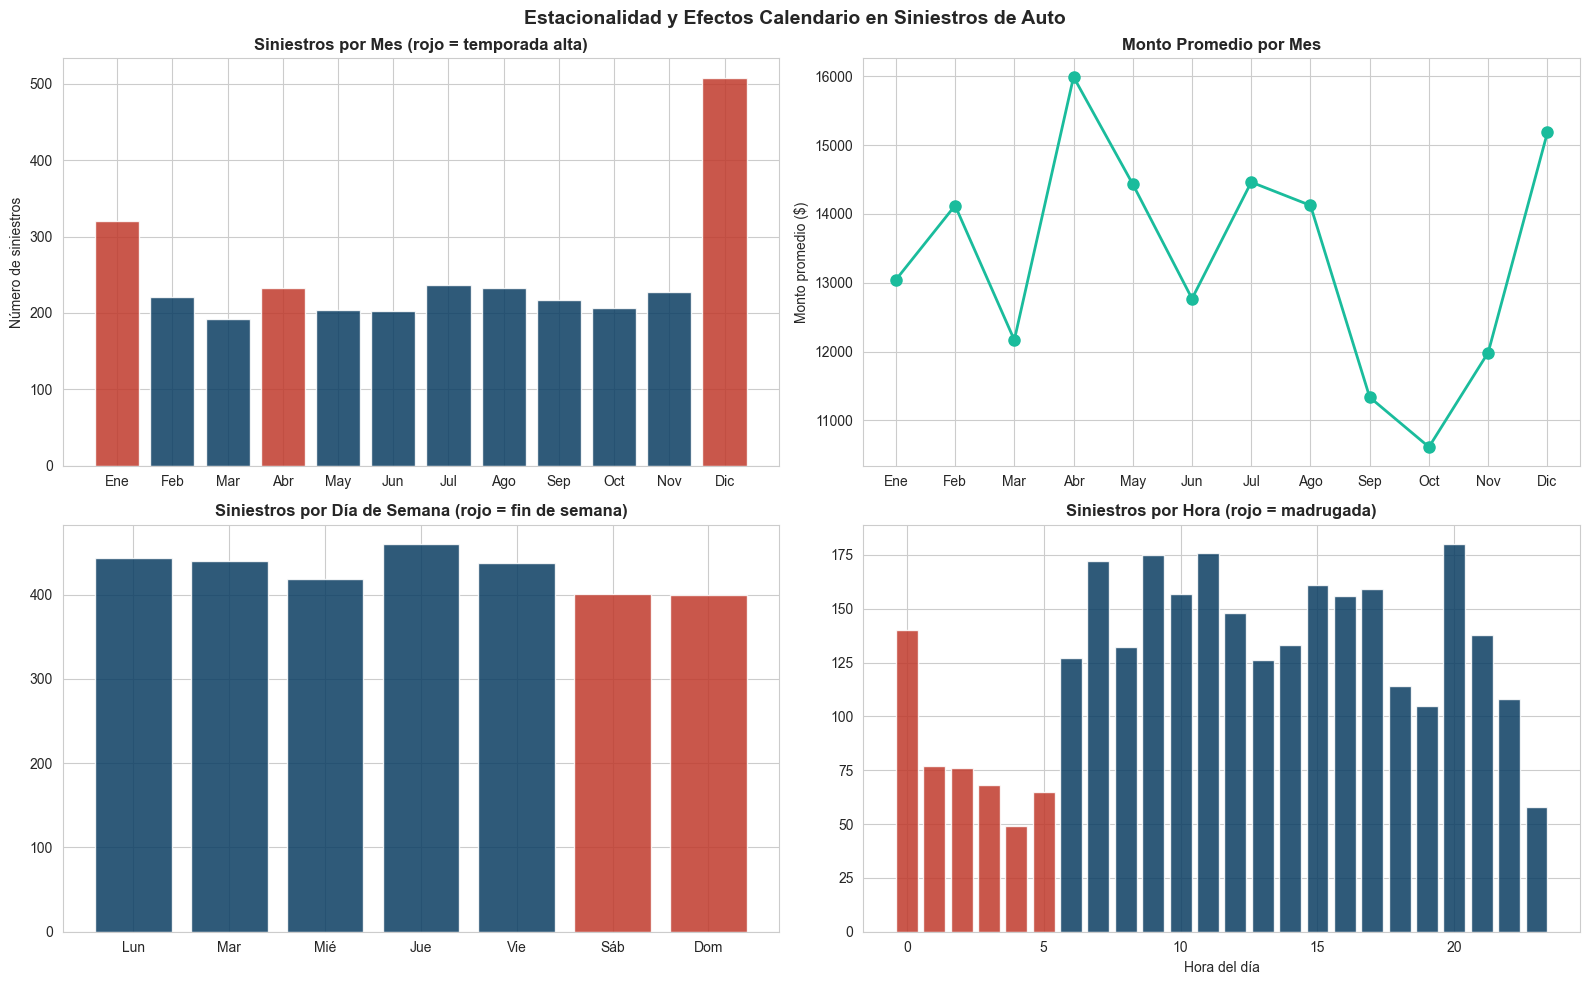

In [5]:
# Visualizar estacionalidad
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Siniestros por mes
sin_mes = df_sin.groupby('mes').size()
colors_mes = ['#C0392B' if m in [1, 4, 12] else '#0A3D62' for m in sin_mes.index]
bars = axes[0,0].bar(range(1, 13), sin_mes.values, color=colors_mes, alpha=0.85, edgecolor='white')
axes[0,0].set_xticks(range(1, 13))
axes[0,0].set_xticklabels(list(nombres_meses.values()))
axes[0,0].set_title('Siniestros por Mes (rojo = temporada alta)', fontweight='bold')
axes[0,0].set_ylabel('Número de siniestros')

# Monto promedio por mes
monto_mes = df_sin.groupby('mes')['monto_siniestro'].mean()
axes[0,1].plot(range(1, 13), monto_mes.values, 'o-', color='#1ABC9C', linewidth=2, markersize=8)
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(list(nombres_meses.values()))
axes[0,1].set_title('Monto Promedio por Mes', fontweight='bold')
axes[0,1].set_ylabel('Monto promedio ($)')

# Siniestros por día de semana
dias_nombres = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
sin_dia = df_sin.groupby('dia_semana').size()
colors_dia = ['#C0392B' if d >= 5 else '#0A3D62' for d in range(7)]
axes[1,0].bar(range(7), sin_dia.values, color=colors_dia, alpha=0.85, edgecolor='white')
axes[1,0].set_xticks(range(7))
axes[1,0].set_xticklabels(dias_nombres)
axes[1,0].set_title('Siniestros por Día de Semana (rojo = fin de semana)', fontweight='bold')

# Siniestros por hora
sin_hora = df_sin.groupby('hora_siniestro').size()
colors_hora = ['#C0392B' if h < 6 else '#0A3D62' for h in range(24)]
axes[1,1].bar(range(24), sin_hora.values, color=colors_hora, alpha=0.85, edgecolor='white')
axes[1,1].set_title('Siniestros por Hora (rojo = madrugada)', fontweight='bold')
axes[1,1].set_xlabel('Hora del día')

plt.suptitle('Estacionalidad y Efectos Calendario en Siniestros de Auto', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('estacionalidad.png', dpi=120, bbox_inches='tight')
plt.show()


## 2. Segmentación de Riesgo

Crear bandas de riesgo a partir de variables continuas usando conocimiento actuarial.


In [6]:
# Segmentación de riesgo por edad del conductor
bins_edad = [0, 25, 30, 50, 65, 200]
labels_riesgo_edad = ['Alto (< 25)', 'Moderado (25-30)', 'Normal (30-50)', 'Moderado (50-65)', 'Alto (65+)']
df_sin['riesgo_edad'] = pd.cut(df_sin['edad_conductor'], bins=bins_edad, labels=labels_riesgo_edad, right=False)

# Segmentación por IMC (seguro de salud)
bins_imc = [0, 18.5, 25, 30, 35, 100]
labels_riesgo_imc = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad I', 'Obesidad II+']
df_sin['riesgo_imc'] = pd.cut(df_sin['imc'], bins=bins_imc, labels=labels_riesgo_imc, right=False)

# Segmentación por antigüedad del vehículo
bins_vehiculo = [0, 2, 5, 10, 15, 100]
labels_riesgo_vehiculo = ['Nuevo', 'Reciente', 'Mediano', 'Antiguo', 'Muy antiguo']
df_sin['riesgo_vehiculo'] = pd.cut(df_sin['antiguedad_vehiculo'], bins=bins_vehiculo, labels=labels_riesgo_vehiculo, right=False)

# Análisis: monto promedio por segmento
print("📊 Monto promedio de siniestro por riesgo de edad:")
print(df_sin.groupby('riesgo_edad', observed=True)['monto_siniestro'].agg(['mean', 'count', 'std']).round(0))


📊 Monto promedio de siniestro por riesgo de edad:
                     mean  count      std
riesgo_edad                              
Alto (< 25)       12615.0    334  14603.0
Moderado (25-30)  13389.0    228  15283.0
Normal (30-50)    13506.0    973  17489.0
Moderado (50-65)  13984.0    756  21069.0
Alto (65+)        13675.0    709  17718.0


## 3. Ratios y Variables Derivadas

Crear índices actuariales que combinan múltiples variables.


In [7]:
# Ratios actuariales fundamentales
epsilon = 1e-6  # Evitar división por cero

# Frecuencia de siniestros normalizada por exposición
df_sin['frecuencia_normalizada'] = df_sin['n_siniestros_previos'] / (df_sin['exposicion'] + epsilon)

# Ratio prima / suma asegurada (tasa de prima)
df_sin['tasa_prima'] = df_sin['prima_anual'] / (df_sin['suma_asegurada'] + epsilon)

# Carga siniestral del asegurado
df_sin['carga_siniestral_previa'] = df_sin['monto_siniestros_previos'] / (df_sin['prima_anual'] + epsilon)

# Severidad media previa por asegurado
df_sin['severidad_previa'] = np.where(
    df_sin['n_siniestros_previos'] > 0,
    df_sin['monto_siniestros_previos'] / df_sin['n_siniestros_previos'],
    0
)

# Índice de valor del vehículo vs prima
df_sin['ratio_sa_prima'] = df_sin['suma_asegurada'] / (df_sin['prima_anual'] + epsilon)

print("📊 Ratios actuariales creados:")
cols_ratios = ['frecuencia_normalizada', 'tasa_prima', 'carga_siniestral_previa', 
               'severidad_previa', 'ratio_sa_prima']
print(df_sin[cols_ratios].describe().round(4))


📊 Ratios actuariales creados:
       frecuencia_normalizada  tasa_prima  carga_siniestral_previa  \
count               3000.0000   3000.0000                3000.0000   
mean                   0.7529      0.0474                   0.0816   
std                    1.7065      0.0294                   0.2712   
min                    0.0000      0.0064                   0.0000   
25%                    0.0000      0.0275                   0.0000   
50%                    0.0000      0.0407                   0.0000   
75%                    1.0487      0.0589                   0.0228   
max                   17.5472      0.3318                   5.7711   

       severidad_previa  ratio_sa_prima  
count         3000.0000       3000.0000  
mean           361.7378         29.0116  
std           1993.9877         17.3874  
min              0.0000          3.0141  
25%              0.0000         16.9706  
50%              0.0000         24.5519  
75%              0.0000         36.4178  
max

📊 Correlación con monto del siniestro actual:


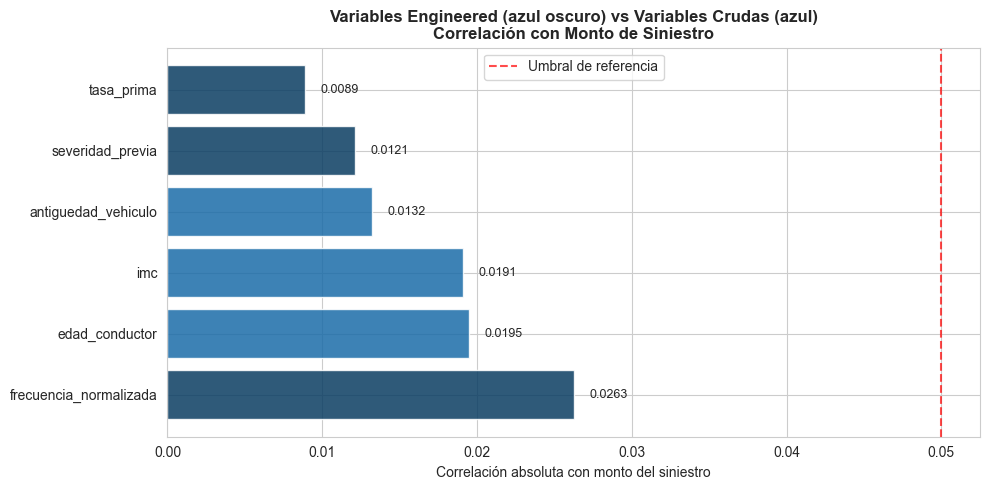


💡 Las variables engineered capturan patrones que las variables crudas no pueden ver directamente


In [8]:
# Análisis de correlación: ¿las nuevas variables predicen mejor?
print("📊 Correlación con monto del siniestro actual:")
cols_analisis = ['edad_conductor', 'imc', 'antiguedad_vehiculo', 
                 'frecuencia_normalizada', 'tasa_prima', 'severidad_previa']

correlaciones = df_sin[cols_analisis + ['monto_siniestro']].corr()['monto_siniestro'].drop('monto_siniestro')
correlaciones = correlaciones.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#0A3D62' if c in ['frecuencia_normalizada', 'severidad_previa', 'tasa_prima'] 
          else '#1B6CA8' for c in correlaciones.index]
bars = ax.barh(correlaciones.index, correlaciones.values, color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Correlación absoluta con monto del siniestro')
ax.set_title('Variables Engineered (azul oscuro) vs Variables Crudas (azul)\nCorrelación con Monto de Siniestro', 
             fontweight='bold')
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, label='Umbral de referencia')
ax.legend()

for bar, val in zip(bars, correlaciones.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('correlacion_features.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n💡 Las variables engineered capturan patrones que las variables crudas no pueden ver directamente")
